# 05. TCGA Survival Validation

This notebook keeps the dual-endpoint Cox validation path (OS + PFI) with bootstrap C-index confidence intervals.


In [1]:
import os
from pathlib import Path

# Resolve project root robustly (works from notebooks/, project root, or Downloads/).
_needed = ["survival_LIHC_survival.txt", "TCGA.LIHC.sampleMap_HiSeqV2.gz"]
_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "Spatial HCC",
    Path.cwd().parent / "Spatial HCC",
]
for _root in _candidates:
    if all((_root / p).exists() for p in _needed):
        os.chdir(_root)
        break

print("Working directory:", Path.cwd())


Working directory: /Users/prateek/Downloads/Spatial HCC


In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

COLORS = {"R": "#2166ac", "NR": "#d6604d"}

In [3]:
# ============================================================
# Core analysis functions
# ============================================================
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

def load_xena_survival(path):
    return pd.read_csv(path, sep="\t")

def load_xena_expr(path_gz):
    expr = pd.read_csv(path_gz, sep="\t", compression="gzip")
    gene_col = expr.columns[0]
    expr = expr.set_index(gene_col)
    expr.columns = [c[:12] for c in expr.columns]
    expr = expr.loc[~expr.index.duplicated(keep="first")]
    return expr

def score_geneset(expr_df, genes, min_genes=3):
    g = [x for x in genes if x in expr_df.index]
    if len(g) < min_genes:
        return pd.Series(np.nan, index=expr_df.columns)
    X = expr_df.loc[g].T
    Xz = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-9)
    return Xz.mean(axis=1)

GENESETS = {
    "CAF":       ["COL1A1","COL1A2","COL3A1","DCN","LUM","TAGLN","ACTA2","FAP","PDGFRB"],
    "TAM":       ["C1QA","C1QB","C1QC","APOE","LGALS3","SPP1","MRC1","CD163","MARCO"],
    "CYTOTOXIC": ["GZMB","GZMK","PRF1","NKG7","GNLY","IFNG"],
    "EXHAUSTION":["PDCD1","LAG3","HAVCR2","TIGIT","CTLA4","TOX","CXCL13"],
    "BCELL":     ["MS4A1","CD79A","CD74","HLA-DRA","BANK1","CD37","CD19"],
    "MALIGNANT": ["EPCAM","KRT19","KRT8","KRT18","GPC3","ALB","AFP"],
    "STEMNESS":  ["EPCAM","PROM1","KRT19","SOX9","ALDH1A1","CD24","NANOG"],
}

def build_tcga_table(surv_df, expr_df, endpoint="OS"):
    event_col, time_col = endpoint, endpoint + ".time"
    s = surv_df[["_PATIENT", event_col, time_col]].copy()
    s = s.rename(columns={event_col: "event", time_col: "time"})
    s = s.dropna(subset=["event", "time"])
    s["event"] = s["event"].astype(int)
    s["time"]  = s["time"].astype(float)
    common = sorted(set(expr_df.columns) & set(s["_PATIENT"]))
    s = s[s["_PATIENT"].isin(common)].set_index("_PATIENT").loc[common].reset_index()
    e = expr_df[common]
    scores = pd.DataFrame(index=e.columns)
    for name, genes in GENESETS.items():
        scores[name] = score_geneset(e, genes)
    df = s.merge(scores.reset_index().rename(columns={"index": "_PATIENT"}),
                 on="_PATIENT", how="inner").dropna()
    return df

def fit_cox_and_bootstrap(df, penalizer=0.1, n_boot=1000, seed=42):
    X = df.drop(columns=["_PATIENT"]).copy()
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(X, duration_col="time", event_col="event")
    rng = np.random.default_rng(seed)
    cidx = []
    for _ in range(n_boot):
        samp = X.sample(frac=1.0, replace=True,
                        random_state=int(rng.integers(0, int(1e9))))
        m = CoxPHFitter(penalizer=penalizer)
        m.fit(samp, duration_col="time", event_col="event")
        ph = m.predict_partial_hazard(X)
        cidx.append(concordance_index(X["time"], -ph.values.ravel(), X["event"]))
    return cph, np.array(cidx)

RUN_MODE = os.environ.get("HCC_RUN_MODE", "full").strip().lower()
N_BOOT   = 1000 if RUN_MODE == "full" else 200

SURV_PATH = "survival_LIHC_survival.txt"
EXPR_PATH = "TCGA.LIHC.sampleMap_HiSeqV2.gz"

surv_all = load_xena_survival(SURV_PATH)
expr     = load_xena_expr(EXPR_PATH)

results = {}
for ep in ["OS", "PFI"]:
    df = build_tcga_table(surv_all, expr, endpoint=ep)
    print(f"\nEndpoint: {ep}  N={df.shape[0]}")
    cph, cidx = fit_cox_and_bootstrap(df, penalizer=0.1, n_boot=N_BOOT)
    print(f"  C-index: {cidx.mean():.3f}  95% CI [{np.quantile(cidx,0.025):.3f}, {np.quantile(cidx,0.975):.3f}]")
    cph.print_summary()
    results[ep] = {"df": df, "cph": cph, "cidx": cidx}


Endpoint: OS  N=533
  C-index: 0.608  95% CI [0.582, 0.626]


<lifelines.CoxPHFitter: fitted with 533 total observations, 296 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 533
number of events observed = 237
   partial log-likelihood = -1271.11
         time fit was run = 2026-03-06 00:57:04 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
CAF        -0.05      0.95      0.08           -0.21            0.11                0.81                1.12
TAM         0.46      1.58      0.13            0.21            0.70                1.23                2.02
CYTOTOXIC  -0.18      0.84      0.10           -0.38            0.02                0.68                1.02
EXHAUSTION  0.08      1.08      0.12           -0.16            0.31                0.85                1.37
BCELL      -0.20      0.81      0.11           -0.42            0.01                0.66                1.01
MALIGNANT   0.02      1.02      0.14           -0.25            0.28                0.78                1.32
STEMNESS    0.15      1.16      0.14           -0.13            0.43                0.88                1.54

            cmp to     z      p  -log2(p)
covariate                                
CAF           0.00 -0.57   0.57      0.81
TAM           0.00  3.62 <0.005     11.72
CYTOTOXIC     0.00 -1.75   0.08      3.64
EXHAUSTION    0.00  0.64   0.52      0.95
BCELL         0.00 -1.90   0.06      4.11
MALIGNANT     0.00  0.12   0.91      0.14
STEMNESS      0.00  1.05   0.29      1.78
---
Concordance = 0.62
Partial AIC = 2556.23
log-likelihood ratio test = 19.29 on 7 df
-log2(p) of ll-ratio test = 7.09


Endpoint: PFI  N=533
  C-index: 0.598  95% CI [0.568, 0.617]


<lifelines.CoxPHFitter: fitted with 533 total observations, 260 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 533
number of events observed = 273
   partial log-likelihood = -1482.91
         time fit was run = 2026-03-06 00:57:25 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
CAF        -0.11      0.90      0.08           -0.26            0.05                0.77                1.05
TAM         0.16      1.17      0.12           -0.07            0.39                0.93                1.48
CYTOTOXIC  -0.27      0.76      0.10           -0.46           -0.08                0.63                0.93
EXHAUSTION  0.14      1.15      0.12           -0.08            0.37                0.92                1.45
BCELL      -0.16      0.86      0.10           -0.36            0.05                0.70                1.05
MALIGNANT  -0.07      0.94      0.13           -0.32            0.19                0.73                1.21
STEMNESS    0.13      1.14      0.14           -0.13            0.40                0.87                1.49

            cmp to     z    p  -log2(p)
covariate                              
CAF           0.00 -1.37 0.17      2.55
TAM           0.00  1.33 0.18      2.45
CYTOTOXIC     0.00 -2.73 0.01      7.29
EXHAUSTION    0.00  1.23 0.22      2.19
BCELL         0.00 -1.50 0.13      2.91
MALIGNANT     0.00 -0.51 0.61      0.71
STEMNESS      0.00  0.98 0.33      1.60
---
Concordance = 0.61
Partial AIC = 2979.82
log-likelihood ratio test = 17.67 on 7 df
-log2(p) of ll-ratio test = 6.21

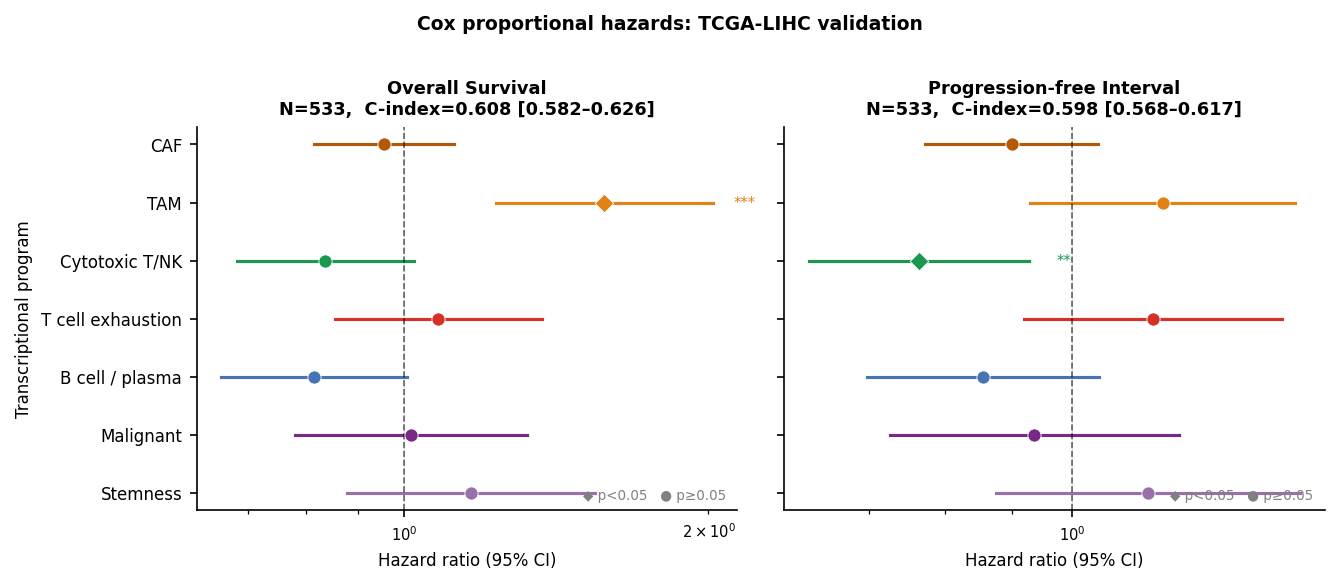

Saved: Fig_TCGA_forest_OS_PFI.png


In [4]:
# ============================================================
# Figure A — Forest plot: Cox hazard ratios, OS and PFI
# Produces: Fig_TCGA_forest_OS_PFI.png
# ============================================================
PROGRAM_LABELS = {
    "CAF":        "CAF",
    "TAM":        "TAM",
    "CYTOTOXIC":  "Cytotoxic T/NK",
    "EXHAUSTION": "T cell exhaustion",
    "BCELL":      "B cell / plasma",
    "MALIGNANT":  "Malignant",
    "STEMNESS":   "Stemness",
}
PROGRAM_COLORS = {
    "CAF":        "#b35806",
    "TAM":        "#e08214",
    "CYTOTOXIC":  "#1a9850",
    "EXHAUSTION": "#d73027",
    "BCELL":      "#4575b4",
    "MALIGNANT":  "#762a83",
    "STEMNESS":   "#9970ab",
}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, ep in zip(axes, ["OS", "PFI"]):
    cph = results[ep]["cph"]
    cidx = results[ep]["cidx"]
    N = results[ep]["df"].shape[0]

    # Extract HR, CI for each program
    summary = cph.summary.copy()
    programs = [p for p in GENESETS if p in summary.index]

    hrs    = np.exp(summary.loc[programs, "coef"].values)
    lo     = np.exp(summary.loc[programs, "coef lower 95%"].values)
    hi     = np.exp(summary.loc[programs, "coef upper 95%"].values)
    pvals  = summary.loc[programs, "p"].values
    labels = [PROGRAM_LABELS[p] for p in programs]
    colors = [PROGRAM_COLORS[p] for p in programs]

    y = np.arange(len(programs))[::-1]

    for i, (hr, l, h, pv, col) in enumerate(zip(hrs, lo, hi, pvals, colors)):
        ax.plot([l, h], [y[i], y[i]], color=col, lw=1.5, zorder=2)
        marker = "D" if pv < 0.05 else "o"
        ax.scatter(hr, y[i], color=col, s=40, zorder=3, marker=marker,
                   edgecolors="white", linewidths=0.4)

    ax.axvline(1.0, color="black", lw=0.8, ls="--", alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI)", fontsize=8)

    ci_mean = cidx.mean()
    ci_lo, ci_hi = np.quantile(cidx, [0.025, 0.975])
    ep_label = "Overall Survival" if ep == "OS" else "Progression-free Interval"
    ax.set_title(f"{ep_label}\nN={N},  C-index={ci_mean:.3f} [{ci_lo:.3f}–{ci_hi:.3f}]",
                 fontsize=8.5, fontweight="bold")
    ax.set_xscale("log")
    ax.grid(axis="x", alpha=0.3, lw=0.5)
    ax.spines[["top","right"]].set_visible(False)

    # significance asterisks
    for i, pv in enumerate(pvals):
        if pv < 0.001:   marker = "***"
        elif pv < 0.01:  marker = "**"
        elif pv < 0.05:  marker = "*"
        else:            marker = ""
        if marker:
            ax.text(hi[i]*1.05, y[i], marker, va="center", fontsize=7,
                    color=colors[i])

    note = "◆ p<0.05   ● p≥0.05"
    ax.text(0.98, 0.02, note, transform=ax.transAxes, fontsize=6.5,
            ha="right", va="bottom", color="gray")

axes[0].set_ylabel("Transcriptional program", fontsize=8)
fig.suptitle("Cox proportional hazards: TCGA-LIHC validation", fontsize=9,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("Fig_TCGA_forest_OS_PFI.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: Fig_TCGA_forest_OS_PFI.png")

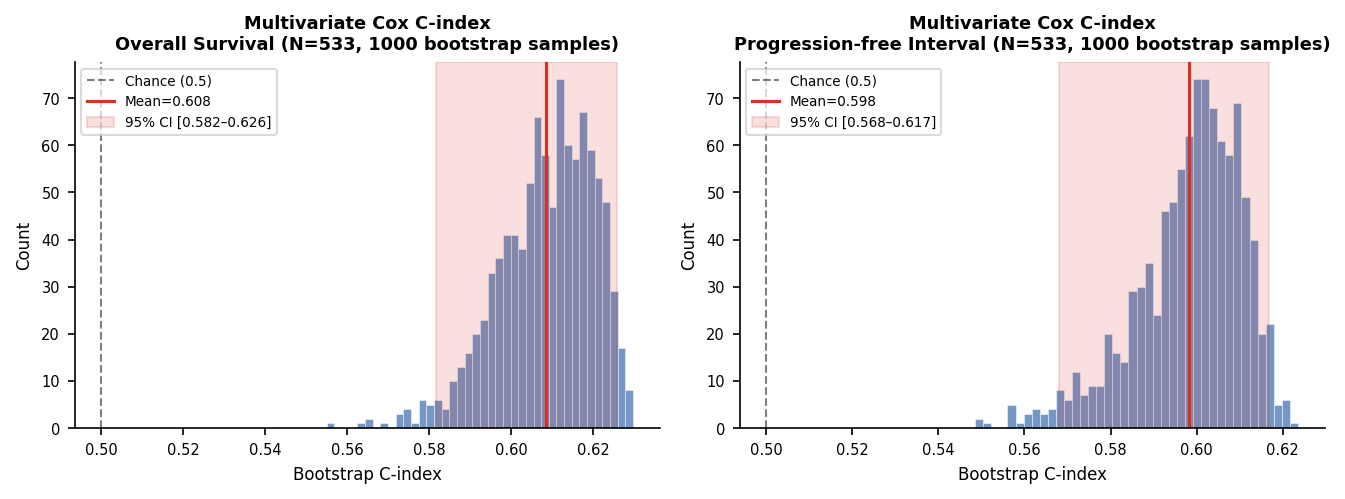

Saved: Fig_TCGA_cindex_bootstrap.png


In [5]:
# ============================================================
# Figure B — Bootstrap C-index distributions + individual program ablation
# Produces: Fig_TCGA_cindex_bootstrap.png
# ============================================================

# Also compute per-program univariate C-index for context
def univariate_cindex(df, program, ep_col="time", ev_col="event"):
    """Univariate C-index for a single program score."""
    clean = df[[program, ep_col, ev_col]].dropna()
    score = clean[program].values
    return concordance_index(clean[ep_col], -score, clean[ev_col])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

for ax, ep in zip(axes, ["OS", "PFI"]):
    cidx = results[ep]["cidx"]
    df_ep = results[ep]["df"]

    # Bootstrap distribution
    ax.hist(cidx, bins=40, color="#4575b4", alpha=0.75, edgecolor="white", lw=0.3)
    ci_lo, ci_hi = np.quantile(cidx, [0.025, 0.975])
    ci_mean = cidx.mean()
    ax.axvline(0.5, color="black", lw=1.0, ls="--", alpha=0.5, label="Chance (0.5)")
    ax.axvline(ci_mean, color="#d73027", lw=1.5, label=f"Mean={ci_mean:.3f}")
    ax.axvspan(ci_lo, ci_hi, alpha=0.15, color="#d73027",
               label=f"95% CI [{ci_lo:.3f}–{ci_hi:.3f}]")

    # Individual program univariate C-indices as rug marks
    uni_cidx = {}
    for prog in GENESETS:
        if prog in df_ep.columns:
            c = univariate_cindex(df_ep, prog)
            uni_cidx[prog] = c

    ax.set_xlabel("Bootstrap C-index", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ep_label = "Overall Survival" if ep == "OS" else "Progression-free Interval"
    ax.set_title(f"Multivariate Cox C-index\n{ep_label} (N={df_ep.shape[0]}, {N_BOOT} bootstrap samples)",
                 fontsize=8.5, fontweight="bold")
    ax.legend(fontsize=6.5, framealpha=0.7)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("Fig_TCGA_cindex_bootstrap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: Fig_TCGA_cindex_bootstrap.png")

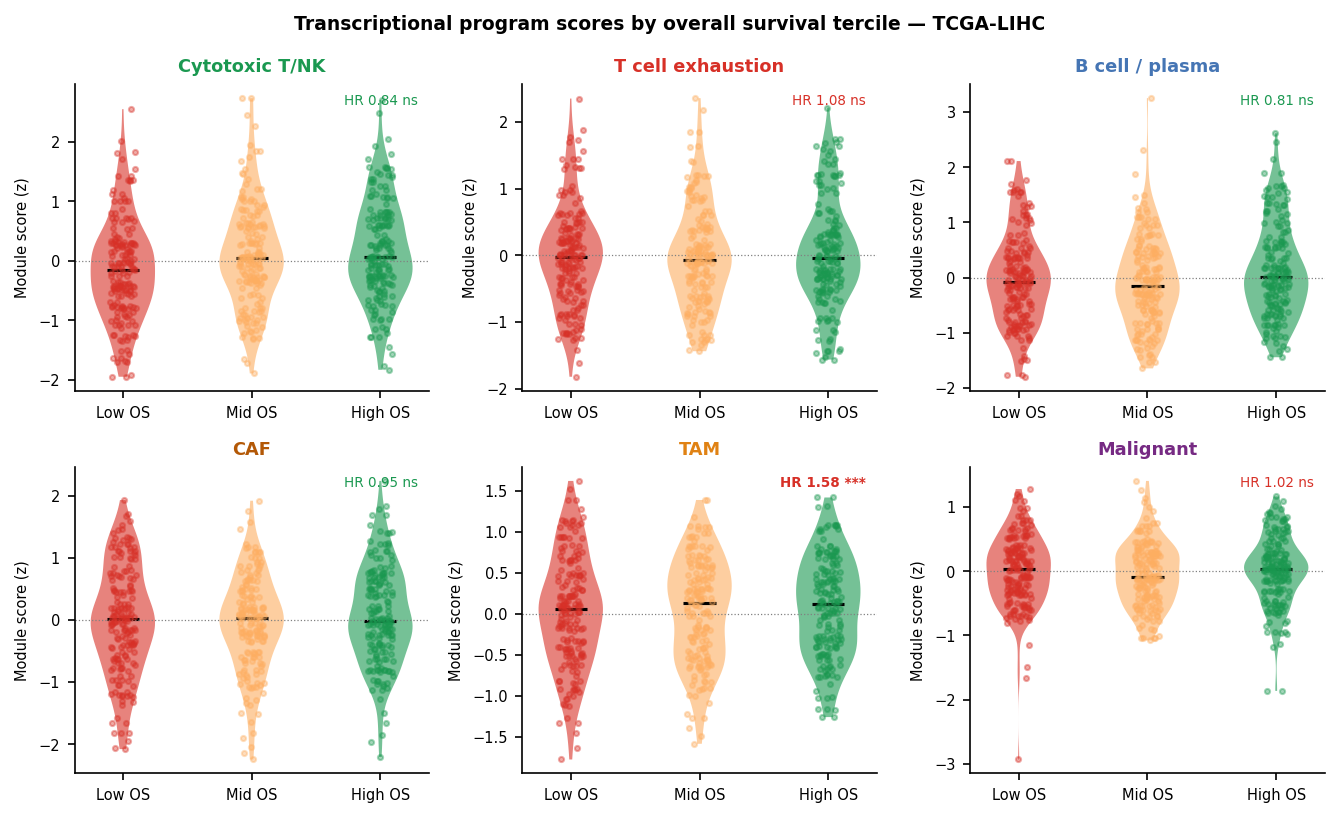

Saved: Fig_TCGA_program_survival_violin.png


In [6]:
# ============================================================
# Figure C — Program score distributions by OS tercile (TCGA-LIHC)
# Produces: Fig_TCGA_program_survival_violin.png
# ============================================================
import matplotlib.ticker as mticker

df_os = results["OS"]["df"].copy()

# Bin patients into OS terciles
df_os["OS_tercile"] = pd.qcut(df_os["time"], q=3,
                               labels=["Low\n(early death)", "Mid", "High\n(long survival)"])

programs_to_show = ["CYTOTOXIC", "EXHAUSTION", "BCELL", "CAF", "TAM", "MALIGNANT"]
labels_show      = [PROGRAM_LABELS[p] for p in programs_to_show]

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5), sharey=False)
axes_flat = axes.flatten()

tercile_colors = ["#d73027", "#fdae61", "#1a9850"]
tercile_labels = ["Low OS", "Mid OS", "High OS"]

for ax, prog, label in zip(axes_flat, programs_to_show, labels_show):
    data_by_tercile = [
        df_os.loc[df_os["OS_tercile"] == t, prog].dropna().values
        for t in df_os["OS_tercile"].cat.categories
    ]

    parts = ax.violinplot(data_by_tercile, positions=[1, 2, 3],
                          showmedians=True, showextrema=False)
    for pc, col in zip(parts["bodies"], tercile_colors):
        pc.set_facecolor(col)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.5)

    # Overlay individual points with jitter
    for xi, (dat, col) in enumerate(zip(data_by_tercile, tercile_colors), start=1):
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(dat))
        ax.scatter(xi + jitter, dat, color=col, alpha=0.4, s=6, zorder=3)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Low OS", "Mid OS", "High OS"], fontsize=7)
    ax.set_ylabel("Module score (z)", fontsize=7)
    ax.set_title(label, fontsize=8.5, fontweight="bold",
                 color=PROGRAM_COLORS[prog])
    ax.axhline(0, color="gray", lw=0.6, ls=":")
    ax.spines[["top","right"]].set_visible(False)

    # Add HR direction annotation
    cph_os = results["OS"]["cph"]
    if prog in cph_os.summary.index:
        coef = cph_os.summary.loc[prog, "coef"]
        pval = cph_os.summary.loc[prog, "p"]
        direction = "↑ risk" if coef > 0 else "↓ risk"
        pstar = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
        ax.text(0.97, 0.97, f"HR {np.exp(coef):.2f} {pstar}",
                transform=ax.transAxes, ha="right", va="top", fontsize=6.5,
                color="#d73027" if coef > 0 else "#1a9850",
                fontweight="bold" if pstar != "ns" else "normal")

fig.suptitle("Transcriptional program scores by overall survival tercile — TCGA-LIHC",
             fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_TCGA_program_survival_violin.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: Fig_TCGA_program_survival_violin.png")

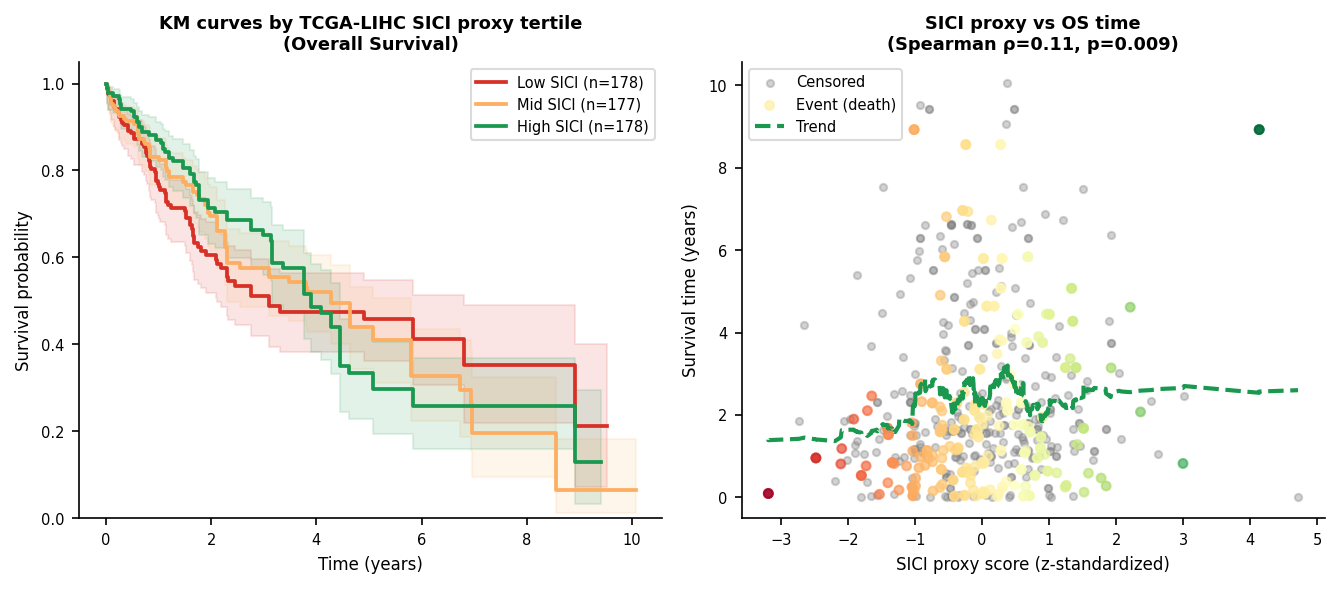

Saved: Fig_TCGA_SICI_surrogate_OS.png


In [7]:
# ============================================================
# Figure D — TCGA coordination surrogate (proxy SICI) vs OS
# Produces: Fig_TCGA_SICI_surrogate_OS.png
# ============================================================
from lifelines import KaplanMeierFitter

df_os = results["OS"]["df"].copy()

# Construct bulk surrogate: alpha*BCELL + beta*(-MALIGNANT*CAF_interaction) + gamma*CYTOTOXIC
# Since bulk RNA-seq lacks spatial coupling, we use:
#   - BCELL score   ≈ B cell–cytotoxic coordination proxy (high = more TLS-like)
#   - (-CAF*MALIGNANT product) ≈ anti-correlated malignant-CAF = better coordination
#   - CYTOTOXIC–EXHAUSTION ratio ≈ cytotoxic balance proxy
df_os["SICI_proxy"] = (
    df_os["BCELL"]
    + (-df_os["CAF"] * df_os["MALIGNANT"])          # malignant-CAF antagonism proxy
    + (df_os["CYTOTOXIC"] - df_os["EXHAUSTION"])    # cytotoxic/exhaustion balance
)
df_os["SICI_proxy_z"] = (df_os["SICI_proxy"] - df_os["SICI_proxy"].mean()) / df_os["SICI_proxy"].std()

# Tertile split on SICI proxy
df_os["SICI_tertile"] = pd.qcut(df_os["SICI_proxy_z"], q=3,
                                  labels=["Low SICI", "Mid SICI", "High SICI"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: KM curves by SICI tertile
ax = axes[0]
kmf = KaplanMeierFitter()
km_colors = ["#d73027", "#fdae61", "#1a9850"]
for t, col in zip(["Low SICI", "Mid SICI", "High SICI"], km_colors):
    mask = df_os["SICI_tertile"] == t
    kmf.fit(df_os.loc[mask, "time"] / 365,
            event_observed=df_os.loc[mask, "event"],
            label=f"{t} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=col, ci_show=True,
                               ci_alpha=0.12, linewidth=1.8)

ax.set_xlabel("Time (years)", fontsize=8)
ax.set_ylabel("Survival probability", fontsize=8)
ax.set_title("KM curves by TCGA-LIHC SICI proxy tertile\n(Overall Survival)",
             fontsize=8.5, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, framealpha=0.7)
ax.spines[["top","right"]].set_visible(False)

# Right: scatter SICI proxy vs OS time (survivors grey-coded)
ax2 = axes[1]
censored = df_os["event"] == 0
events   = df_os["event"] == 1

ax2.scatter(df_os.loc[censored, "SICI_proxy_z"],
            df_os.loc[censored, "time"] / 365,
            color="gray", alpha=0.35, s=12, label="Censored", zorder=2)
ax2.scatter(df_os.loc[events, "SICI_proxy_z"],
            df_os.loc[events, "time"] / 365,
            c=df_os.loc[events, "SICI_proxy_z"],
            cmap="RdYlGn", alpha=0.7, s=18, zorder=3, label="Event (death)")

# Loess-style trend via moving average
sorted_idx = df_os["SICI_proxy_z"].argsort()
x_s = df_os["SICI_proxy_z"].iloc[sorted_idx].values
y_s = (df_os["time"] / 365).iloc[sorted_idx].values
window = max(20, len(x_s) // 10)
y_smooth = pd.Series(y_s).rolling(window, center=True, min_periods=5).mean().values
ax2.plot(x_s, y_smooth, color="#1a9850", lw=2, ls="--", label="Trend", zorder=4)

from scipy.stats import spearmanr
rho, pval = spearmanr(df_os["SICI_proxy_z"], df_os["time"])
ax2.set_xlabel("SICI proxy score (z-standardized)", fontsize=8)
ax2.set_ylabel("Survival time (years)", fontsize=8)
ax2.set_title(f"SICI proxy vs OS time\n(Spearman ρ={rho:.2f}, p={pval:.3f})",
              fontsize=8.5, fontweight="bold")
ax2.legend(fontsize=7, framealpha=0.7)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("Fig_TCGA_SICI_surrogate_OS.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: Fig_TCGA_SICI_surrogate_OS.png")

In [8]:
# ============================================================
# Print all key statistics for paper writeup
# ============================================================
from scipy.stats import spearmanr

print("=" * 60)
print("KEY STATISTICS FOR PAPER")
print("=" * 60)

for ep in ["OS", "PFI"]:
    cph  = results[ep]["cph"]
    cidx = results[ep]["cidx"]
    df   = results[ep]["df"]
    N    = df.shape[0]
    ci_mean = cidx.mean()
    ci_lo, ci_hi = np.quantile(cidx, [0.025, 0.975])

    print(f"\n--- {ep} endpoint (N={N}) ---")
    print(f"  C-index: {ci_mean:.3f} (95% CI {ci_lo:.3f}–{ci_hi:.3f})")

    for prog in ["CYTOTOXIC","BCELL","EXHAUSTION","TAM","CAF","MALIGNANT"]:
        if prog in cph.summary.index:
            row = cph.summary.loc[prog]
            hr   = np.exp(row["coef"])
            lo_h = np.exp(row["coef lower 95%"])
            hi_h = np.exp(row["coef upper 95%"])
            pv   = row["p"]
            print(f"  {prog:12s}: HR={hr:.2f} [{lo_h:.2f}–{hi_h:.2f}], p={pv:.4f}")

# SICI proxy correlation
df_os = results["OS"]["df"].copy()
df_os["SICI_proxy"] = (
    df_os["BCELL"]
    + (-df_os["CAF"] * df_os["MALIGNANT"])
    + (df_os["CYTOTOXIC"] - df_os["EXHAUSTION"])
)
rho, pval = spearmanr(df_os["SICI_proxy"], df_os["time"])
print(f"\nSICI proxy vs OS time: Spearman ρ={rho:.3f}, p={pval:.4f}")

N_cyto_sig = int((results["OS"]["df"]["CYTOTOXIC"] > 0).sum())
print(f"\nN with positive CYTOTOXIC score: {N_cyto_sig}/{len(results['OS']['df'])}")

KEY STATISTICS FOR PAPER

--- OS endpoint (N=533) ---
  C-index: 0.608 (95% CI 0.582–0.626)
  CYTOTOXIC   : HR=0.84 [0.68–1.02], p=0.0804
  BCELL       : HR=0.81 [0.66–1.01], p=0.0578
  EXHAUSTION  : HR=1.08 [0.85–1.37], p=0.5193
  TAM         : HR=1.58 [1.23–2.02], p=0.0003
  CAF         : HR=0.95 [0.81–1.12], p=0.5715
  MALIGNANT   : HR=1.02 [0.78–1.32], p=0.9082

--- PFI endpoint (N=533) ---
  C-index: 0.598 (95% CI 0.568–0.617)
  CYTOTOXIC   : HR=0.76 [0.63–0.93], p=0.0064
  BCELL       : HR=0.86 [0.70–1.05], p=0.1328
  EXHAUSTION  : HR=1.15 [0.92–1.45], p=0.2190
  TAM         : HR=1.17 [0.93–1.48], p=0.1826
  CAF         : HR=0.90 [0.77–1.05], p=0.1709
  MALIGNANT   : HR=0.94 [0.73–1.21], p=0.6094

SICI proxy vs OS time: Spearman ρ=0.113, p=0.0093

N with positive CYTOTOXIC score: 262/533
